# MRNet Extra Credit Analysis

## Extra Credit Items From The Project PDF

The brief offers up to **15 extra marks** total, split across five items worth up to **3 marks each**:

1. **Multi-plane fusion**: train separate models for sagittal, coronal, and axial planes, combine predictions, and compare against the best single-plane result.
2. **Feature space visualisation**: extract `[CLS]` embeddings for validation images, project them into 2-D with t-SNE or UMAP, and discuss clustering.
3. **Weights & Biases integration**: log experiments and include a public W&B project link.
4. **Systematic error analysis**: inspect the most confidently incorrect validation cases and discuss likely causes.
5. **Project-style implementation**: modular Python files, CLI entry point, and pinned dependencies.

This notebook focuses on the items that fit naturally into a notebook-only workflow: **multi-plane analysis**, **feature-space visualisation**, and **systematic error analysis**.


In [ ]:
from __future__ import annotations

import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

PROJECT_ROOT = Path('/Users/yaseenahmed/Documents/EEEM068-MRNet-ViT')
DATA_DIR = Path('/Users/yaseenahmed/Downloads/MRNet-v1.0')
BEST_MODEL_CKPT = PROJECT_ROOT / 'best_model.pth'
SINGLE_PLANE_METRICS_CSV = PROJECT_ROOT / 'validation_metrics.csv'
MULTIPLANE_METRICS_CSV = PROJECT_ROOT / 'multiplane_validation_metrics.csv'
SINGLE_PLANE_PRED_CSV = PROJECT_ROOT / 'validation_predictions.csv'
MULTIPLANE_PRED_CSV = PROJECT_ROOT / 'multiplane_validation_predictions.csv'
OOD_DIR = PROJECT_ROOT / 'OOD_images'

LABELS = ['abnormal', 'acl', 'meniscus']
PLANE = 'sagittal'
N_SLICES = 5
IMG_SIZE = 224
BATCH_SIZE = 8
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

config_df = pd.DataFrame(
    {
        'key': ['device', 'data_dir', 'best_model_ckpt', 'single_plane_metrics', 'multiplane_metrics'],
        'value': [str(DEVICE), str(DATA_DIR), str(BEST_MODEL_CKPT), str(SINGLE_PLANE_METRICS_CSV), str(MULTIPLANE_METRICS_CSV)],
    }
)
display(config_df)


,key,value
0,device,mps
1,data_dir,/Users/yaseenahmed/Documents/ML project/MRNet-...
2,best_model_ckpt,/Users/yaseenahmed/Documents/ML project/best_m...
3,single_plane_metrics,/Users/yaseenahmed/Documents/ML project/valida...
4,multiplane_metrics,/Users/yaseenahmed/Documents/ML project/multip...


## 1. Multi-Plane Fusion Analysis

This section uses the **existing saved CSV artefacts** already present in the workspace. ; it simply compares their saved validation metrics side by side.


In [2]:
single_df = pd.read_csv(SINGLE_PLANE_METRICS_CSV).rename(columns={'class': 'condition'})
multi_df = pd.read_csv(MULTIPLANE_METRICS_CSV).rename(columns={'class': 'condition'})

comparison_df = single_df.merge(multi_df, on='condition', suffixes=('_single_plane', '_multiplane'))
for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']:
    comparison_df[f'delta_{metric}'] = comparison_df[f'{metric}_multiplane'] - comparison_df[f'{metric}_single_plane']

display(comparison_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df = comparison_df.melt(
    id_vars='condition',
    value_vars=['auc_roc_single_plane', 'auc_roc_multiplane'],
    var_name='model_type',
    value_name='auc_roc'
)
plot_df['model_type'] = plot_df['model_type'].map({
    'auc_roc_single_plane': 'Single-plane',
    'auc_roc_multiplane': 'Multi-plane fusion'
})

sns.barplot(data=plot_df, x='condition', y='auc_roc', hue='model_type', ax=axes[0])
axes[0].set_title('AUC-ROC: Single-plane vs Multi-plane')
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.2)

heatmap_df = comparison_df.set_index('condition')[[
    'delta_accuracy', 'delta_precision', 'delta_recall', 'delta_f1', 'delta_auc_roc'
]]
sns.heatmap(heatmap_df.round(3), annot=True, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Multi-plane minus Single-plane')

plt.tight_layout()
plt.show()

summary_lines = []
for _, row in comparison_df.iterrows():
    if row['delta_auc_roc'] > 0:
        verdict = 'improves'
    elif row['delta_auc_roc'] < 0:
        verdict = 'underperforms'
    else:
        verdict = 'matches'
    summary_lines.append(f"{row['condition']}: multi-plane {verdict} single-plane by {row['delta_auc_roc']:.4f} AUC")

print('\n'.join(summary_lines))


FileNotFoundError: [Errno 2] No such file or directory: '/Users/yaseenahmed/Documents/ML project/validation_metrics.csv'

## 2. Validation Dataset And Report-Grade ViT Checkpoint

For the remaining extra-credit items, this notebook loads the stronger **report-style single-plane ViT checkpoint** from `best_model.pth`. That checkpoint is compatible with embedding extraction and attention-map visualisation.


In [ ]:
class MRNetDatasetWithID(Dataset):
    def __init__(self, data_dir, plane, split, transform=None, n_slices=5, augment=False):
        self.data_dir = Path(data_dir)
        self.plane = plane
        self.split = split
        self.transform = transform
        self.n_slices = n_slices
        self.augment = augment

        dfs = []
        for label in LABELS:
            csv_path = self.data_dir / f'{split}-{label}.csv'
            df = pd.read_csv(csv_path, header=None, names=['exam_id', label])
            dfs.append(df.set_index('exam_id'))

        self.labels_df = pd.concat(dfs, axis=1).reset_index()
        self.labels_df['exam_id'] = self.labels_df['exam_id'].astype(int)
        self.vol_dir = self.data_dir / split / plane

    @staticmethod
    def _to_rgb(slice_2d):
        mn, mx = slice_2d.min(), slice_2d.max()
        if mx > mn:
            arr = ((slice_2d - mn) / (mx - mn) * 255).astype(np.uint8)
        else:
            arr = np.zeros_like(slice_2d, dtype=np.uint8)
        return Image.fromarray(arr, mode='L').convert('RGB')

    def _sample_indices(self, total_slices):
        indices = np.round(np.linspace(0, total_slices - 1, self.n_slices)).astype(int)
        if self.augment:
            offsets = np.random.randint(-1, 2, size=self.n_slices)
            indices = np.clip(indices + offsets, 0, total_slices - 1)
        return indices

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        exam_id = int(row['exam_id'])
        label = torch.tensor(row[LABELS].values.astype(np.float32))

        volume = np.load(self.vol_dir / f'{exam_id:04d}.npy')
        indices = self._sample_indices(volume.shape[0])

        slices = []
        for index in indices:
            img = self._to_rgb(volume[index])
            if self.transform is not None:
                img = self.transform(img)
            slices.append(img)

        return torch.stack(slices, dim=0), label, f'{exam_id:04d}'


val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_dataset = MRNetDatasetWithID(DATA_DIR, PLANE, 'valid', transform=val_transform, n_slices=N_SLICES, augment=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Validation exams: {len(val_dataset)}')
print(f'Validation batches: {len(val_loader)}')


Validation exams: 120
Validation batches: 15


In [ ]:
class MRNetViT(nn.Module):
    def __init__(self, n_labels=3, n_slices=5):
        super().__init__()
        self.n_slices = n_slices
        self.backbone = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=0)
        embed_dim = self.backbone.embed_dim
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_labels),
        )

    def forward(self, x):
        bsz, slices, ch, h, w = x.shape
        x_flat = x.view(bsz * slices, ch, h, w)
        feats = self.backbone(x_flat)
        logits = self.head(feats)
        logits = logits.view(bsz, slices, -1).mean(dim=1)
        return logits

    def get_last_attention(self, x_single_slice):
        last_block = self.backbone.blocks[-1]
        original_fused = getattr(last_block.attn, 'fused_attn', False)
        last_block.attn.fused_attn = False

        attn_output = []

        def hook_fn(module, inputs, output):
            attn_output.append(output)

        handle = last_block.attn.attn_drop.register_forward_hook(hook_fn)
        with torch.no_grad():
            _ = self.backbone(x_single_slice)
        handle.remove()
        last_block.attn.fused_attn = original_fused
        return attn_output[0]


model = MRNetViT(n_labels=len(LABELS), n_slices=N_SLICES).to(DEVICE)
checkpoint = torch.load(BEST_MODEL_CKPT, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()

print(f'Loaded checkpoint from epoch: {checkpoint.get("epoch")}')
print(f'Best validation loss recorded in checkpoint: {checkpoint.get("val_loss"):.4f}')


Loaded checkpoint from epoch: 2
Best validation loss recorded in checkpoint: 0.6429


## 3. Feature Space Visualisation

The brief asks for `[CLS]`-token embeddings projected into 2-D using t-SNE or UMAP. Since the `timm` backbone returns the final ViT representation for each slice, this notebook averages the per-slice embeddings into one exam-level feature vector, then applies **PCA + t-SNE**.


Extract embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Embedding matrix shape: (120, 384)


,exam_id,tsne_x,tsne_y,abnormal,acl,meniscus,abnormal_prob,acl_prob,meniscus_prob
0,1130,-6.571002,-4.710916,0,0,0,0.138414,0.215950,0.016664
1,1131,-3.979584,-4.714236,0,0,0,0.565054,0.708253,0.254016
2,1132,-6.365640,-4.225627,0,0,0,0.094387,0.090863,0.007849
3,1133,-5.150259,-4.080902,0,0,0,0.080815,0.186920,0.060396
4,1134,-3.007316,3.868860,0,0,0,0.473691,0.229078,0.276364


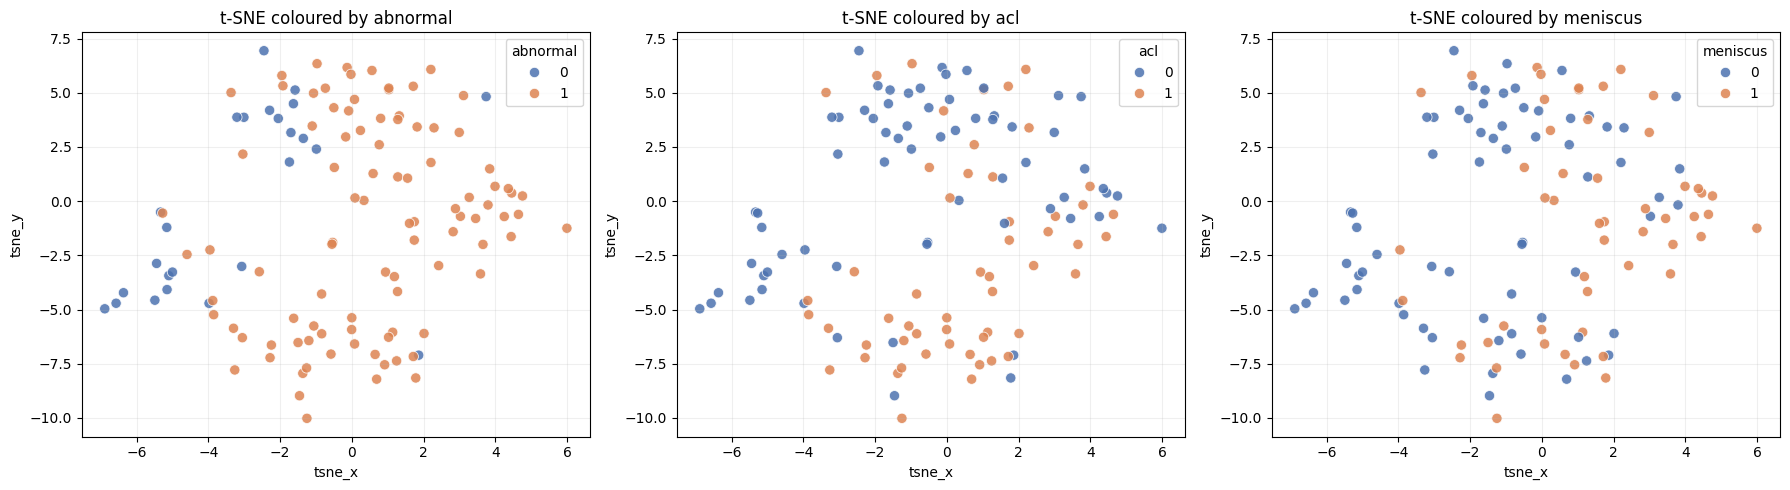

In [ ]:
@torch.no_grad()
def extract_exam_embeddings(model, loader):
    exam_ids = []
    all_labels = []
    all_probs = []
    all_embeddings = []

    for slices, labels, batch_ids in tqdm(loader, desc='Extract embeddings'):
        slices = slices.to(DEVICE)
        labels = labels.to(DEVICE)

        bsz, n_slices, ch, h, w = slices.shape
        x_flat = slices.view(bsz * n_slices, ch, h, w)
        slice_embeddings = model.backbone(x_flat)
        exam_embeddings = slice_embeddings.view(bsz, n_slices, -1).mean(dim=1)

        logits = model.head(slice_embeddings).view(bsz, n_slices, -1).mean(dim=1)
        probs = torch.sigmoid(logits)

        exam_ids.extend(batch_ids)
        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_embeddings.append(exam_embeddings.cpu().numpy())

    return (
        exam_ids,
        np.concatenate(all_labels, axis=0),
        np.concatenate(all_probs, axis=0),
        np.concatenate(all_embeddings, axis=0),
    )


exam_ids, labels_np, probs_np, embeddings_np = extract_exam_embeddings(model, val_loader)
print('Embedding matrix shape:', embeddings_np.shape)

pca_dims = min(50, embeddings_np.shape[1], len(embeddings_np) - 1)
embeddings_pca = PCA(n_components=pca_dims, random_state=SEED).fit_transform(embeddings_np)
perplexity = min(30, max(5, len(embeddings_np) // 4))
embeddings_2d = TSNE(
    n_components=2,
    random_state=SEED,
    init='pca',
    learning_rate='auto',
    perplexity=perplexity,
).fit_transform(embeddings_pca)

embedding_df = pd.DataFrame({
    'exam_id': exam_ids,
    'tsne_x': embeddings_2d[:, 0],
    'tsne_y': embeddings_2d[:, 1],
    'abnormal': labels_np[:, 0].astype(int),
    'acl': labels_np[:, 1].astype(int),
    'meniscus': labels_np[:, 2].astype(int),
    'abnormal_prob': probs_np[:, 0],
    'acl_prob': probs_np[:, 1],
    'meniscus_prob': probs_np[:, 2],
})

display(embedding_df.head())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, label in enumerate(LABELS):
    sns.scatterplot(
        data=embedding_df,
        x='tsne_x',
        y='tsne_y',
        hue=label,
        palette={0: '#4C72B0', 1: '#DD8452'},
        alpha=0.85,
        s=55,
        ax=axes[idx],
    )
    axes[idx].set_title(f't-SNE coloured by {label}')
    axes[idx].grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 4. Systematic Error Analysis

The brief asks for the validation examples where the model is **most confidently incorrect**. Here, confidence error is approximated by the mean binary cross-entropy loss per exam. The notebook then surfaces the top failures and attaches a suggested hypothesis that you can adapt directly into the report.


In [ ]:
@torch.no_grad()
def collect_validation_outputs(model, loader, threshold=0.5):
    rows = []
    for slices, labels, batch_ids in tqdm(loader, desc='Collect validation outputs'):
        slices = slices.to(DEVICE)
        labels = labels.to(DEVICE)
        logits = model(slices)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).int()
        losses = nn.functional.binary_cross_entropy_with_logits(logits, labels, reduction='none').mean(dim=1)

        for i, exam_id in enumerate(batch_ids):
            true_vec = labels[i].int().cpu().numpy().tolist()
            pred_vec = preds[i].cpu().numpy().tolist()
            prob_vec = probs[i].cpu().numpy().tolist()
            wrong_labels = [label for label, t, p in zip(LABELS, true_vec, pred_vec) if t != p]
            rows.append({
                'exam_id': exam_id,
                'sample_loss': float(losses[i].cpu()),
                'true_vector': true_vec,
                'pred_vector': pred_vec,
                'true_labels': [label for label, flag in zip(LABELS, true_vec) if flag == 1],
                'pred_labels': [label for label, flag in zip(LABELS, pred_vec) if flag == 1],
                'wrong_labels': wrong_labels,
                'abnormal_prob': prob_vec[0],
                'acl_prob': prob_vec[1],
                'meniscus_prob': prob_vec[2],
            })
    return pd.DataFrame(rows)


def suggest_hypothesis(row):
    true_labels = row['true_labels']
    pred_labels = row['pred_labels']
    wrong_labels = row['wrong_labels']

    if len(true_labels) == 0 and len(pred_labels) > 0:
        return 'False positive on a nominally normal exam. Possible causes: confounding bright structures, unusual anatomy, or attention drifting to non-diagnostic tissue.'
    if len(true_labels) > 0 and len(pred_labels) == 0:
        return 'False negative. Possible causes: subtle pathology, pathology lying outside the sampled slices, or limited sensitivity from using only one plane.'
    if 'abnormal' in wrong_labels and ('acl' in true_labels or 'meniscus' in true_labels):
        return 'The model may recognise local damage but fail to map it cleanly to the broader abnormal label threshold.'
    if {'acl', 'meniscus'} & set(wrong_labels):
        return 'Label-specific confusion. ACL and meniscus findings can share surrounding edema or degenerative signal, especially when only a few slices are sampled.'
    return 'Likely caused by subtle image evidence, slice-selection limits, or ambiguous MRI appearance relative to the training distribution.'


error_df = collect_validation_outputs(model, val_loader)
error_df['is_wrong'] = error_df['wrong_labels'].apply(lambda items: len(items) > 0)
error_df['suggested_hypothesis'] = error_df.apply(suggest_hypothesis, axis=1)

top_errors = error_df[error_df['is_wrong']].sort_values('sample_loss', ascending=False).reset_index(drop=True)

display(top_errors[['exam_id', 'sample_loss', 'true_labels', 'pred_labels', 'wrong_labels', 'suggested_hypothesis']].head(10))


Collect validation outputs:   0%|          | 0/15 [00:00<?, ?it/s]

,exam_id,sample_loss,true_labels,pred_labels,wrong_labels,suggested_hypothesis
0,1137,3.587376,[],"[abnormal, acl, meniscus]","[abnormal, acl, meniscus]",False positive on a nominally normal exam. Pos...
1,1151,1.568479,[],"[abnormal, meniscus]","[abnormal, meniscus]",False positive on a nominally normal exam. Pos...
2,1242,1.422912,"[abnormal, meniscus]","[abnormal, acl, meniscus]",[acl],Label-specific confusion. ACL and meniscus fin...
3,1187,1.338316,"[abnormal, acl]","[abnormal, meniscus]","[acl, meniscus]",Label-specific confusion. ACL and meniscus fin...
4,1171,1.292503,[abnormal],"[abnormal, acl, meniscus]","[acl, meniscus]",Label-specific confusion. ACL and meniscus fin...
5,1219,1.086451,"[abnormal, acl]",[],"[abnormal, acl]",False negative. Possible causes: subtle pathol...
6,1227,0.957199,"[abnormal, meniscus]","[abnormal, acl, meniscus]",[acl],Label-specific confusion. ACL and meniscus fin...
7,1172,0.944699,"[abnormal, acl, meniscus]",[abnormal],"[acl, meniscus]",Label-specific confusion. ACL and meniscus fin...
8,1183,0.937566,"[abnormal, acl]","[abnormal, meniscus]","[acl, meniscus]",Label-specific confusion. ACL and meniscus fin...
9,1140,0.848165,[],"[abnormal, acl]","[abnormal, acl]",False positive on a nominally normal exam. Pos...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].


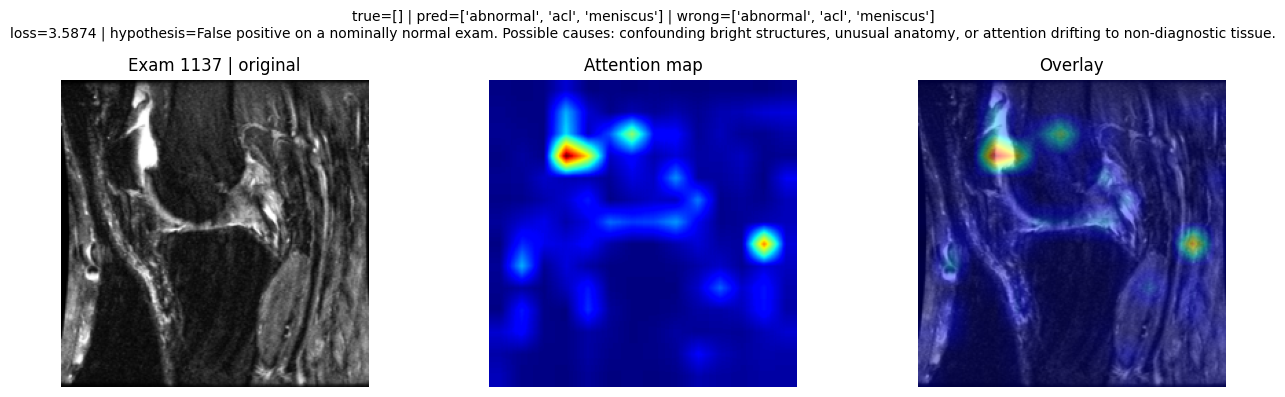

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].


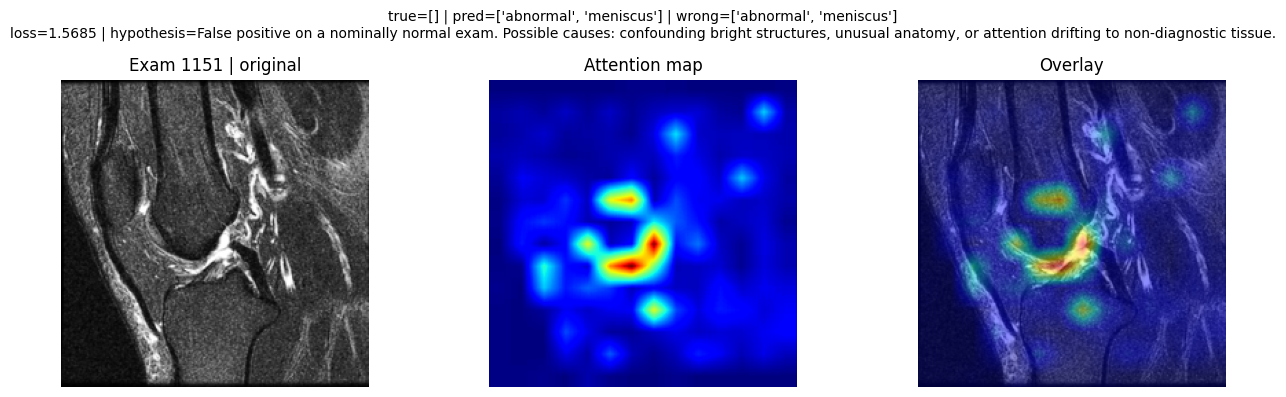

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].


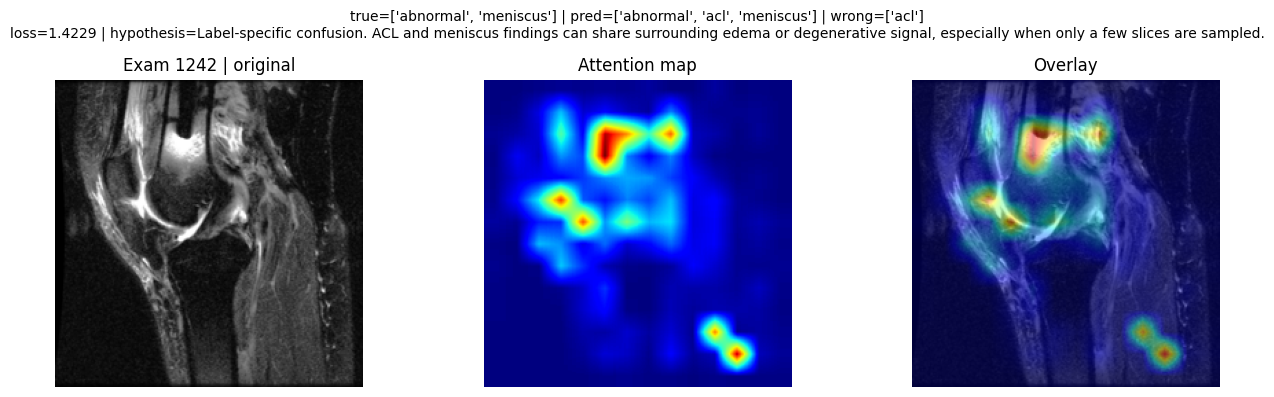

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].


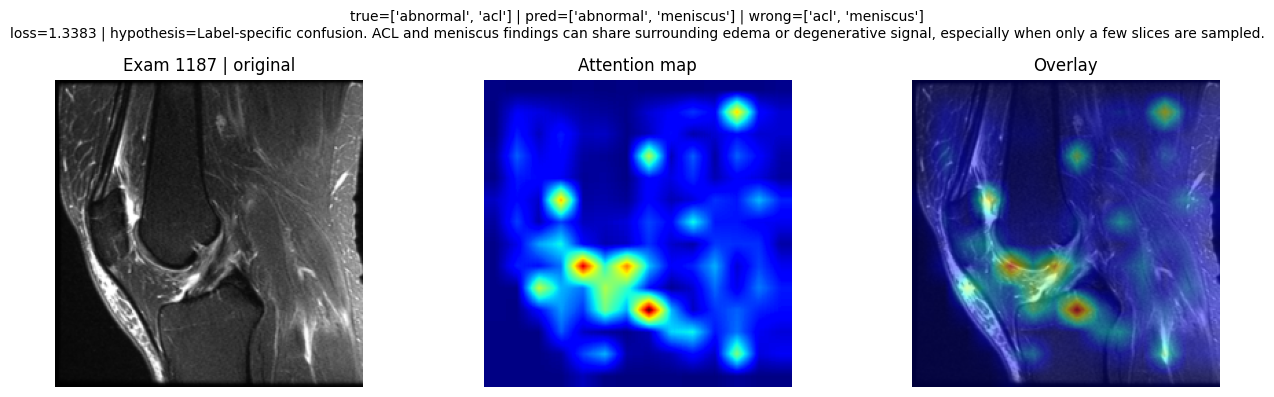

In [ ]:
def denormalize_image(tensor_img):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = tensor_img.cpu() * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


def build_attention_map(model, image_tensor):
    attn = model.get_last_attention(image_tensor.unsqueeze(0).to(DEVICE)).squeeze(0)
    cls_attn = attn[:, 0, 1:].mean(dim=0)
    patch_grid = int(math.sqrt(cls_attn.shape[0]))
    attn_map = cls_attn.reshape(patch_grid, patch_grid).cpu().numpy()
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
    attn_map = np.array(
        Image.fromarray((attn_map * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE), resample=Image.BILINEAR)
    ) / 255.0
    return attn_map


def show_top_error_attention_cases(top_k=4):
    exam_to_idx = {val_dataset[i][2]: i for i in range(len(val_dataset))}
    selected = top_errors.head(top_k)

    for _, row in selected.iterrows():
        slices, label_tensor, exam_id = val_dataset[exam_to_idx[row['exam_id']]]
        middle = len(slices) // 2
        image_tensor = slices[middle]
        original = denormalize_image(image_tensor)
        attention_map = build_attention_map(model, image_tensor)
        overlay = 0.55 * original + 0.45 * plt.cm.jet(attention_map)[..., :3]

        fig, axes = plt.subplots(1, 3, figsize=(13, 4))
        axes[0].imshow(original)
        axes[0].set_title(f'Exam {exam_id} | original')
        axes[0].axis('off')

        axes[1].imshow(attention_map, cmap='jet')
        axes[1].set_title('Attention map')
        axes[1].axis('off')

        axes[2].imshow(overlay)
        axes[2].set_title('Overlay')
        axes[2].axis('off')

        title = (
            f"true={row['true_labels']} | pred={row['pred_labels']} | wrong={row['wrong_labels']}\n"
            f"loss={row['sample_loss']:.4f} | hypothesis={row['suggested_hypothesis']}"
        )
        plt.suptitle(title, fontsize=10)
        plt.tight_layout()
        plt.show()


show_top_error_attention_cases(top_k=4)


## Report Notes

How to use this notebook in the report:
- Use the **multi-plane table and bar chart** to discuss whether fusion helped or hurt each condition.
- Use the **t-SNE plots** to comment on class separability and whether better clustering lines up with better AUC.
- Use the **top-error table and overlays** to support a qualitative failure analysis section.

What is **not** covered here:
- W&B integration, because that needs an online logging setup.
- Project-style implementation, because that requires refactoring the codebase into modules and CLI entry points rather than notebook-only work.
